In [1]:
from datetime import datetime
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db
from wpp.utils import project_root

In [3]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [4]:
query = """with x as (
    select DATE_RANGE_START, VISITOR_COUNT, ST_Centroid(bgh.GEOM) as centroid, p.geom, ST_Distance_Sphere(centroid, p.geom) as dist
    from block_group_visits bgv
    join block_groups bgh on bgv.HOME_GEOID = bgh.GEOID
    join pois p on bgv.ID_STORE = p.ID_STORE
    where bgh.statefp = '12'
)
select
    date_range_start,
    sum(visitor_count) as visitor_count,
    sum(dist * visitor_count) / sum(visitor_count) as avg_dist
from x
group by 1"""
df = con.sql(query).pl()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

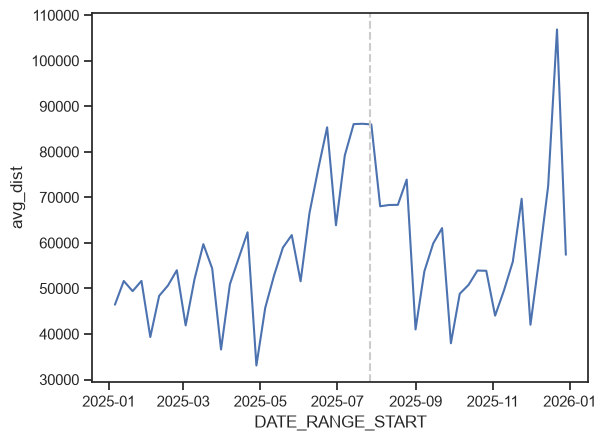

In [8]:
heatwave_date = datetime.fromisoformat("2025-07-27")
ax = sns.lineplot(df, x="DATE_RANGE_START", y="avg_dist")
ax.axvline(heatwave_date, color="#ccc", linestyle="--")

In [ ]:
query = """with x as (
    select DATE_RANGE_START, bgh.COUNTYFP, VISITOR_COUNT, ST_Centroid(bgh.GEOM) as centroid, p.geom, ST_Distance_Sphere(centroid, p.geom) as dist
    from block_group_visits bgv
    join block_groups bgh on bgv.HOME_GEOID = bgh.GEOID
    join pois p on bgv.ID_STORE = p.ID_STORE
    where bgh.statefp = '12'
)
select
    date_range_start, countyfp,
    sum(visitor_count) as visitor_count,
    sum(dist * visitor_count) / sum(visitor_count) as avg_dist
from x
group by 1, 2"""
counties = con.sql(query).pl()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

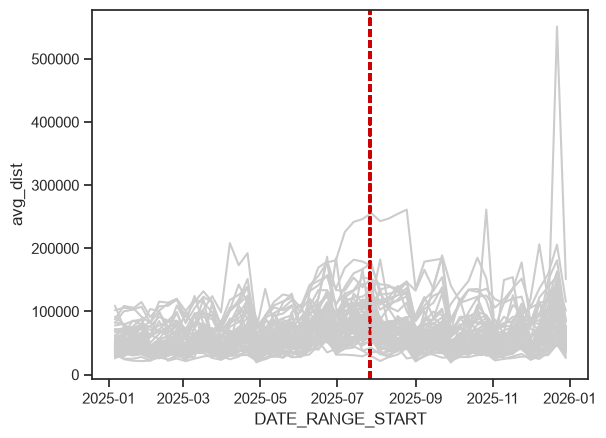

In [21]:
fig, ax = plt.subplots()
groups = counties.group_by("COUNTYFP")
for county, cdf in groups:
    sns.lineplot(cdf, x="DATE_RANGE_START", y="avg_dist", color="#ccc", legend=False, ax=ax)
    ax.axvline(heatwave_date, color="#c00", linestyle="--")